# Phase 2 — Rigorous QPINN Investigation

**ETH Quantum Hackathon 2026 — Quandela Challenge**

Scientific question: *Does the MerLin quantum component actually help, or is it just an expensive nonlinear function approximator?*

This notebook implements:
- Parameter-matched classical PINN baselines
- MerLin auxiliary-derivative QPINN
- MerLin direct second-derivative QPINN
- Controlled expressivity sweeps via `CircuitBuilder`
- Temporal extrapolation generalization test
- Resource / runtime / energy-proxy analysis
- Honest, evidence-based conclusion


In [1]:
import matplotlib
matplotlib.use("Agg")

import math, time, random, os, warnings
from dataclasses import dataclass
from typing import Dict, List
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import merlin as ML
import perceval as pcvl

DEVICE = torch.device("cpu")
DTYPE = torch.float32
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"Torch:  {torch.__version__}")
print(f"MerLin: {getattr(ML, '__version__', 'unknown')}")

FAST_MODE = True

if FAST_MODE:
    print("\n=== FAST MODE ===")
    BASE_EPOCHS = 50
    BASE_SEEDS = [0]
    SWEEP_EPOCHS = 50
    SWEEP_SEEDS = [0]
    N_EVAL_X, N_EVAL_T = 51, 51
else:
    print("\n=== FULL MODE ===")
    BASE_EPOCHS = 300
    BASE_SEEDS = [0, 1, 2]
    SWEEP_EPOCHS = 150
    SWEEP_SEEDS = [0]
    N_EVAL_X, N_EVAL_T = 101, 101

os.makedirs("results", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)


Device: cpu
Torch:  2.10.0+cpu
MerLin: 0.2.3

=== FAST MODE ===



## Problem Definition

1-D heat equation on $x \in [-\pi/2, \pi/2]$, $t \in [0, 0.5]$:

$$
\partial_t T = \alpha \, \partial_{xx} T, \quad \alpha = 0.30
$$

Boundary conditions (Dirichlet):
$$
T(-\pi/2, t) = T(\pi/2, t) = 0
$$

Initial condition:
$$
T(x, 0) = \frac12 \exp\!\left(-\frac{(x + \pi/8)^2}{2\sigma^2}\right), \quad \sigma^2 = 0.2
$$


In [2]:

ALPHA = 0.30
X_MIN, X_MAX = -math.pi/2, math.pi/2
T_MIN, T_MAX = 0.0, 0.5
SIGMA2 = 0.2
X0 = -math.pi/8

def initial_condition(x: np.ndarray) -> np.ndarray:
    return 0.5 * np.exp(-(x - X0)**2 / (2 * SIGMA2))

def solve_reference(nx=401, nt_eval=401, t_span=(T_MIN, T_MAX)):
    x = np.linspace(X_MIN, X_MAX, nx)
    dx = x[1] - x[0]
    u0 = initial_condition(x)
    u0_interior = u0[1:-1].astype(np.float64)
    n = nx - 2
    main = -2.0 * np.ones(n)
    off = 1.0 * np.ones(n - 1)
    L = (np.diag(main) + np.diag(off, 1) + np.diag(off, -1)) / (dx**2)
    def rhs(t, u):
        return ALPHA * (L @ u)
    t_eval = np.linspace(t_span[0], t_span[1], nt_eval)
    sol = solve_ivp(rhs, t_span, u0_interior, t_eval=t_eval, method='RK45')
    U = np.zeros((nx, nt_eval))
    U[1:-1, :] = sol.y
    U[0, :] = 0.0
    U[-1, :] = 0.0
    X_grid, T_grid = np.meshgrid(x, t_eval, indexing='ij')
    return X_grid, T_grid, U

print("Computing reference solution...")
X_ref, T_ref, U_ref = solve_reference(nx=401, nt_eval=401)
print(f"Reference grid: {X_ref.shape}, range [{U_ref.min():.4f}, {U_ref.max():.4f}]")

from scipy.interpolate import RegularGridInterpolator

def reference_at(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    x_np = x.detach().cpu().numpy().ravel()
    t_np = t.detach().cpu().numpy().ravel()
    x_vec = np.linspace(X_MIN, X_MAX, X_ref.shape[0])
    t_vec = np.linspace(T_MIN, T_MAX, X_ref.shape[1])
    interp = RegularGridInterpolator((x_vec, t_vec), U_ref, bounds_error=False, fill_value=0.0)
    vals = interp(np.stack([x_np, t_np], axis=1))
    return torch.tensor(vals, dtype=DTYPE, device=DEVICE).view(-1, 1)


Computing reference solution...
Reference grid: (401, 401), range [0.0000, 0.5000]


In [3]:

def gradients(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]

def bc_envelope(x: torch.Tensor) -> torch.Tensor:
    a = math.pi / 2
    return (a**2 - x**2)

def bc_envelope_d1(x: torch.Tensor) -> torch.Tensor:
    return -2.0 * x

def bc_envelope_d2(x: torch.Tensor) -> torch.Tensor:
    return torch.full_like(x, -2.0)


In [4]:

class ClassicalDirectPINN(nn.Module):
    def __init__(self, hidden=32, depth=3):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        q = self.net(xt)
        x = xt[:, 0:1]
        return bc_envelope(x) * q

class ClassicalAuxPINN(nn.Module):
    def __init__(self, hidden=32, depth=3):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 2))
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        out = self.net(xt)
        q = out[:, 0:1]
        qx_hat = out[:, 1:2]
        x = xt[:, 0:1]
        env = bc_envelope(x)
        env_d1 = bc_envelope_d1(x)
        T = env * q
        Tx = env_d1 * q + env * qx_hat
        return T, Tx

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [21]:

class MerlinAuxQPINN(nn.Module):
    def __init__(self, feature_size=4, quantum_output_size=4, hidden=16, depth=1, n_photons=3):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )
        self.n_photons = n_photons
        if depth == 1:
            self.quantum = ML.QuantumLayer.simple(
                input_size=feature_size, output_size=quantum_output_size)
            self.post = nn.Identity()
        else:
            n_modes = max(feature_size + 1, n_photons)
            builder = ML.CircuitBuilder(n_modes=n_modes)
            for i in range(depth):
                builder.add_entangling_layer(trainable=True, name=f"L{i}")
            builder.add_angle_encoding(modes=list(range(feature_size)), name="input")
            for i in range(depth):
                builder.add_entangling_layer(trainable=True, name=f"R{i}")
            circ = builder.to_pcvl_circuit()
            exp = pcvl.Experiment(m_circuit=circ)
            state_list = [1 if idx < n_photons else 0 for idx in range(n_modes)]
            exp.with_input(pcvl.BasicState(state_list))
            self.quantum = ML.QuantumLayer(
                experiment=exp, n_photons=n_photons,
                trainable_parameters=[f"L{i}" for i in range(depth)] + [f"R{i}" for i in range(depth)],
                input_parameters=["input"],
                measurement_strategy=ML.MeasurementStrategy.probs(),
            )
            q_out = self.quantum.output_size
            if q_out != quantum_output_size:
                self.post = ML.ModGrouping(input_size=q_out, output_size=quantum_output_size)
            else:
                self.post = nn.Identity()
        self.depth = depth
        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden), nn.Tanh(),
            nn.Linear(hidden, 2),
        )
    def forward(self, xt):
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        if self.depth > 1:
            q = self.post(q)
        out = self.readout(q)
        q_u = out[:, 0:1]
        qx_hat = out[:, 1:2]
        env = bc_envelope(x)
        env_d1 = bc_envelope_d1(x)
        T = env * q_u
        Tx = env_d1 * q_u + env * qx_hat
        return T, Tx

class MerlinDirectQPINN(nn.Module):
    def __init__(self, feature_size=4, quantum_output_size=4, hidden=16, depth=1, n_photons=3):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )
        self.n_photons = n_photons
        if depth == 1:
            self.quantum = ML.QuantumLayer.simple(
                input_size=feature_size, output_size=quantum_output_size)
            self.post = nn.Identity()
        else:
            n_modes = max(feature_size + 1, n_photons)
            builder = ML.CircuitBuilder(n_modes=n_modes)
            for i in range(depth):
                builder.add_entangling_layer(trainable=True, name=f"L{i}")
            builder.add_angle_encoding(modes=list(range(feature_size)), name="input")
            for i in range(depth):
                builder.add_entangling_layer(trainable=True, name=f"R{i}")
            circ = builder.to_pcvl_circuit()
            exp = pcvl.Experiment(m_circuit=circ)
            state_list = [1 if idx < n_photons else 0 for idx in range(n_modes)]
            exp.with_input(pcvl.BasicState(state_list))
            self.quantum = ML.QuantumLayer(
                experiment=exp, n_photons=n_photons,
                trainable_parameters=[f"L{i}" for i in range(depth)] + [f"R{i}" for i in range(depth)],
                input_parameters=["input"],
                measurement_strategy=ML.MeasurementStrategy.probs(),
            )
            q_out = self.quantum.output_size
            if q_out != quantum_output_size:
                self.post = ML.ModGrouping(input_size=q_out, output_size=quantum_output_size)
            else:
                self.post = nn.Identity()
        self.depth = depth
        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
    def forward(self, xt):
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        if self.depth > 1:
            q = self.post(q)
        q_u = self.readout(q)
        return bc_envelope(x) * q_u


## Photonic Circuit Visualization

Visualize the actual photonic circuits used by the MerLin QPINNs using Perceval.

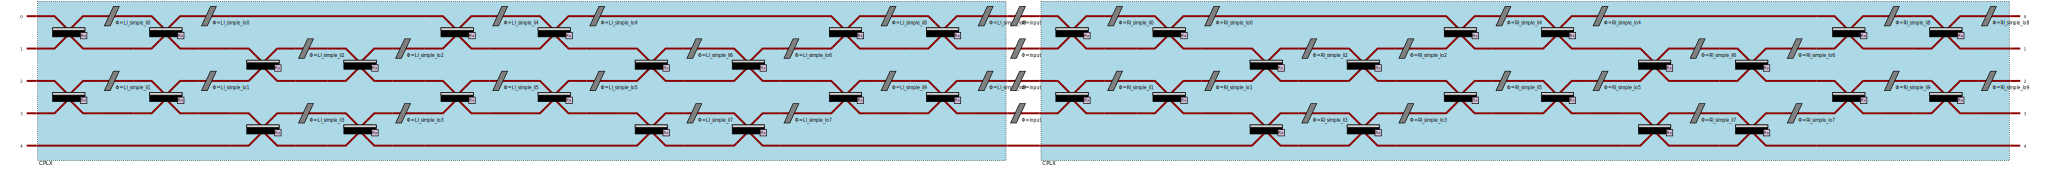

In [6]:

def print_merlin_circuit(feature_size=4, depth=1, save_path=None):
    """Build and display a MerLin photonic circuit."""
    if depth == 1:
        ql = ML.QuantumLayer.simple(input_size=feature_size, output_size=feature_size)
        circ = ql.circuit
    else:
        n_modes = feature_size + 1
        builder = ML.CircuitBuilder(n_modes=n_modes)
        for i in range(depth):
            builder.add_entangling_layer(trainable=True, name=f'L{i}')
        builder.add_angle_encoding(modes=list(range(feature_size)), name='input')
        for i in range(depth):
            builder.add_entangling_layer(trainable=True, name=f'R{i}')
        circ = builder.to_pcvl_circuit()

    print(f"=== MerLin Photonic Circuit (depth={depth}, modes={circ.m}) ===")
    print(f"Total components: {len(circ._components)}")
    print("\nComponent breakdown:")
    for comp in circ._components:
        print(f"  {comp}")

# Build a MerLin Aux model and display its internal photonic circuit
model_viz = MerlinAuxQPINN(feature_size=4, quantum_output_size=4, hidden=16, depth=1)
pcvl.pdisplay(model_viz.quantum.circuit, recursive=True)


In [7]:

@dataclass
class TrainConfig:
    epochs: int = 300
    n_f: int = 128
    n_i: int = 128
    n_b: int = 128
    lr: float = 1e-2
    lambda_pde: float = 1.0
    lambda_ic: float = 10.0
    lambda_bc: float = 1.0
    lambda_consistency: float = 0.1
    print_every: int = 25

def sample_interior(n, device=DEVICE, dtype=DTYPE):
    x = torch.empty(n, 1, device=device, dtype=dtype).uniform_(X_MIN, X_MAX)
    t = torch.empty(n, 1, device=device, dtype=dtype).uniform_(T_MIN, T_MAX)
    return torch.cat([x, t], dim=1)

def sample_initial(n, device=DEVICE, dtype=DTYPE):
    x = torch.empty(n, 1, device=device, dtype=dtype).uniform_(X_MIN, X_MAX)
    t = torch.full((n, 1), T_MIN, device=device, dtype=dtype)
    return torch.cat([x, t], dim=1), reference_at(x, torch.zeros_like(x))

def sample_boundary(n, device=DEVICE, dtype=DTYPE):
    side = torch.rand(n, 1, device=device, dtype=dtype)
    x = torch.where(side < 0.5, torch.full_like(side, X_MIN), torch.full_like(side, X_MAX))
    t = torch.empty(n, 1, device=device, dtype=dtype).uniform_(T_MIN, T_MAX)
    return torch.cat([x, t], dim=1), torch.zeros(n, 1, device=device, dtype=dtype)

def pde_residual_direct(model, xt):
    xt = xt.requires_grad_(True)
    T = model(xt)
    grad_T = gradients(T, xt)
    T_t = grad_T[:, 1:2]
    T_x = grad_T[:, 0:1]
    T_xx = gradients(T_x, xt)[:, 0:1]
    return T_t - ALPHA * T_xx

def pde_residual_aux(model, xt):
    xt = xt.requires_grad_(True)
    T, Tx = model(xt)
    T_t = gradients(T, xt)[:, 1:2]
    Tx_x = gradients(Tx, xt)[:, 0:1]
    r_f = T_t - ALPHA * Tx_x
    T_x_auto = gradients(T, xt)[:, 0:1]
    r_c = T_x_auto - Tx
    return r_f, r_c

def train_model(model, config, mode="direct"):
    model = model.to(device=DEVICE, dtype=DTYPE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
    mse = nn.MSELoss()
    history = {"total": [], "pde": [], "ic": [], "bc": [], "consistency": []}
    start = time.time()
    is_aux = "aux" in mode
    for epoch in range(1, config.epochs + 1):
        optimizer.zero_grad()
        xt_f = sample_interior(config.n_f)
        xt_i, y_i = sample_initial(config.n_i)
        xt_b, y_b = sample_boundary(config.n_b)
        if is_aux:
            r_f, r_c = pde_residual_aux(model, xt_f)
            loss_pde = mse(r_f, torch.zeros_like(r_f))
            loss_cons = mse(r_c, torch.zeros_like(r_c))
            T_i, _ = model(xt_i)
            T_b, _ = model(xt_b)
        else:
            r_f = pde_residual_direct(model, xt_f)
            loss_pde = mse(r_f, torch.zeros_like(r_f))
            loss_cons = torch.tensor(0.0, device=DEVICE, dtype=DTYPE)
            T_i = model(xt_i)
            T_b = model(xt_b)
        loss_ic = mse(T_i, y_i)
        loss_bc = mse(T_b, y_b)
        loss = (config.lambda_pde * loss_pde + config.lambda_ic * loss_ic
                + config.lambda_bc * loss_bc + config.lambda_consistency * loss_cons)
        loss.backward()
        optimizer.step()
        history["total"].append(loss.item())
        history["pde"].append(loss_pde.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())
        history["consistency"].append(loss_cons.item())
        if config.print_every > 0 and (epoch % config.print_every == 0 or epoch == 1):
            print(f"Epoch {epoch:4d} | loss={loss.item():.3e} | pde={loss_pde.item():.3e} | "
                  f"ic={loss_ic.item():.3e} | bc={loss_bc.item():.3e} | cons={loss_cons.item():.3e}")
    elapsed = time.time() - start
    return history, elapsed


In [8]:

def evaluate_model(model, mode="direct", nx=51, nt=51, t_span=(T_MIN, T_MAX)):
    model.eval()
    with torch.no_grad():
        x = torch.linspace(X_MIN, X_MAX, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
        t = torch.linspace(t_span[0], t_span[1], nt, device=DEVICE, dtype=DTYPE).view(-1, 1)
        X, Tmesh = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
        xt = torch.stack([X.reshape(-1), Tmesh.reshape(-1)], dim=1)
        if "aux" in mode:
            T_pred, _ = model(xt)
        else:
            T_pred = model(xt)
        T_pred = T_pred.reshape(nx, nt).cpu().numpy()
    x_vec = np.linspace(X_MIN, X_MAX, X_ref.shape[0])
    t_vec = np.linspace(T_MIN, T_MAX, X_ref.shape[1])
    from scipy.interpolate import RegularGridInterpolator
    interp = RegularGridInterpolator((x_vec, t_vec), U_ref, bounds_error=False, fill_value=0.0)
    X_np = X.cpu().numpy()
    T_np = Tmesh.cpu().numpy()
    T_ref_grid = interp(np.stack([X_np.ravel(), T_np.ravel()], axis=1)).reshape(nx, nt)
    diff = T_pred - T_ref_grid
    rel_l2 = np.linalg.norm(diff) / np.linalg.norm(T_ref_grid)
    rmse = np.sqrt(np.mean(diff**2))
    mae = np.mean(np.abs(diff))
    max_err = np.max(np.abs(diff))
    nmse = np.mean(diff**2) / np.mean(T_ref_grid**2)
    xi = torch.rand(min(2000, nx*nt), 1, device=DEVICE, dtype=DTYPE).uniform_(X_MIN, X_MAX)
    ti = torch.rand(min(2000, nx*nt), 1, device=DEVICE, dtype=DTYPE).uniform_(t_span[0], t_span[1])
    xti = torch.cat([xi, ti], dim=1)
    xti.requires_grad_(True)
    if "aux" in mode:
        r_f, _ = pde_residual_aux(model, xti)
    else:
        r_f = pde_residual_direct(model, xti)
    pde_mse = torch.mean(r_f**2).item()
    xt_ic = sample_initial(500)[0]
    T_ic_pred = model(xt_ic)[0] if "aux" in mode else model(xt_ic)
    T_ic_ref = reference_at(xt_ic[:, 0:1], xt_ic[:, 1:2])
    ic_mse = torch.mean((T_ic_pred - T_ic_ref)**2).item()
    xt_bc, y_bc = sample_boundary(500)
    T_bc_pred = model(xt_bc)[0] if "aux" in mode else model(xt_bc)
    bc_mse = torch.mean((T_bc_pred - y_bc)**2).item()
    return {
        "rel_l2": rel_l2, "rmse": rmse, "mae": mae, "max_err": max_err, "nmse": nmse,
        "pde_mse": pde_mse, "ic_mse": ic_mse, "bc_mse": bc_mse,
        "T_pred": T_pred, "T_ref": T_ref_grid, "X": X_np, "T": T_np,
    }


In [9]:

merlin_ref = MerlinAuxQPINN(feature_size=4, quantum_output_size=4, hidden=16, depth=1)
merlin_params = count_parameters(merlin_ref)
print(f"MerLin Aux QPINN (depth=1) parameters: {merlin_params}")

best_diff = float('inf')
classical_hidden, classical_depth = 32, 3
for hidden, depth in [(8,2),(12,2),(16,2),(32,2),(64,2),(8,3),(12,3),(16,3),(32,3),(8,4),(12,4),(16,4)]:
    p = count_parameters(ClassicalDirectPINN(hidden=hidden, depth=depth))
    if abs(p - merlin_params) < best_diff:
        best_diff = abs(p - merlin_params)
        classical_hidden, classical_depth = hidden, depth
print(f"Classical Direct matched: hidden={classical_hidden}, depth={classical_depth} (diff={best_diff})")

best_diff = float('inf')
aux_hidden, aux_depth = 32, 3
for hidden, depth in [(8,2),(12,2),(14,2),(16,2),(32,2),(64,2),(8,3),(12,3),(14,3),(16,3),(32,3),(8,4),(12,4),(14,4),(16,4)]:
    p = count_parameters(ClassicalAuxPINN(hidden=hidden, depth=depth))
    if abs(p - merlin_params) < best_diff:
        best_diff = abs(p - merlin_params)
        aux_hidden, aux_depth = hidden, depth
print(f"Classical Aux matched:    hidden={aux_hidden}, depth={aux_depth} (diff={best_diff})")

strong_hidden, strong_depth = 32, 4
print(f"Classical Strong:         hidden={strong_hidden}, depth={strong_depth} ({count_parameters(ClassicalDirectPINN(strong_hidden, strong_depth))} params)")


MerLin Aux QPINN (depth=1) parameters: 270
Classical Direct matched: hidden=8, depth=4 (diff=21)
Classical Aux matched:    hidden=14, depth=2 (diff=12)
Classical Strong:         hidden=32, depth=4 (3297 params)


## Baseline Experiments

Train and evaluate classical matched, classical strong, MerLin Aux, and MerLin Direct.


In [10]:

results_rows = []
training_histories = {}

def run_experiment(name, model_builder, config, mode, seeds, analysis="baseline"):
    rows = []
    hist_last = None
    for seed in seeds:
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        model = model_builder()
        for p in model.parameters():
            if p.is_floating_point():
                p.data = p.data.to(DTYPE)
        print(f"\n>>> {name} | seed={seed} | epochs={config.epochs}")
        hist, elapsed = train_model(model, config, mode=mode)
        hist_last = hist
        metrics = evaluate_model(model, mode=mode)
        row = {
            "analysis": analysis, "model": name, "seed": seed, "epochs": config.epochs,
            "params": count_parameters(model), "time": elapsed,
            "rel_l2": metrics["rel_l2"], "rmse": metrics["rmse"], "mae": metrics["mae"],
            "max_err": metrics["max_err"], "nmse": metrics["nmse"],
            "pde_mse": metrics["pde_mse"], "ic_mse": metrics["ic_mse"], "bc_mse": metrics["bc_mse"],
            "final_loss": hist["total"][-1],
        }
        if "merlin" in name.lower():
            ql = None
            for m in model.modules():
                if hasattr(m, 'quantum_layer'):
                    ql = m.quantum_layer; break
            if ql is None and hasattr(model, 'quantum'):
                qmod = model.quantum
                if hasattr(qmod, 'quantum_layer'): ql = qmod.quantum_layer
            if ql is not None:
                row["qumodes"] = getattr(ql, 'n_modes', getattr(ql, 'input_size', 'unknown'))
                row["q_params"] = sum(p.numel() for p in ql.parameters() if p.requires_grad)
                circ = getattr(ql, 'circuit', None)
                row["circuit_depth"] = str(getattr(circ, 'depths', 'unknown')) if circ else "simple"
            else:
                row["qumodes"] = "unknown"; row["q_params"] = "unknown"; row["circuit_depth"] = "unknown"
        else:
            row["qumodes"] = 0; row["q_params"] = 0; row["circuit_depth"] = "N/A"
        rows.append(row)
        print(f"    rel_l2={metrics['rel_l2']:.4e} | pde_mse={metrics['pde_mse']:.4e} | time={elapsed:.1f}s")
    training_histories[name] = hist_last
    return rows, model, metrics

base_cfg = TrainConfig(epochs=BASE_EPOCHS, lr=1e-2, print_every=max(1, BASE_EPOCHS//10))

rows_cd, model_cd, met_cd = run_experiment("Classical Direct (matched)",
    lambda: ClassicalDirectPINN(hidden=classical_hidden, depth=classical_depth),
    base_cfg, "direct", BASE_SEEDS)
results_rows += rows_cd

rows_ca, model_ca, met_ca = run_experiment("Classical Aux (matched)",
    lambda: ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth),
    base_cfg, "aux", BASE_SEEDS)
results_rows += rows_ca

rows_ma, model_ma, met_ma = run_experiment("MerLin Aux (depth=1)",
    lambda: MerlinAuxQPINN(feature_size=4, quantum_output_size=4, hidden=16, depth=1),
    base_cfg, "merlin_aux", BASE_SEEDS)
results_rows += rows_ma

rows_md, model_md, met_md = run_experiment("MerLin Direct (depth=1)",
    lambda: MerlinDirectQPINN(feature_size=4, quantum_output_size=4, hidden=16, depth=1),
    base_cfg, "merlin_direct", BASE_SEEDS)
results_rows += rows_md

rows_cs, model_cs, met_cs = run_experiment("Classical Direct (strong)",
    lambda: ClassicalDirectPINN(hidden=strong_hidden, depth=strong_depth),
    base_cfg, "direct", BASE_SEEDS)
results_rows += rows_cs



>>> Classical Direct (matched) | seed=0 | epochs=50
Epoch    1 | loss=3.619e-01 | pde=9.105e-04 | ic=3.610e-02 | bc=1.851e-16 | cons=0.000e+00
Epoch    5 | loss=1.308e-01 | pde=3.033e-03 | ic=1.278e-02 | bc=8.023e-16 | cons=0.000e+00
Epoch   10 | loss=8.545e-02 | pde=1.466e-02 | ic=7.079e-03 | bc=1.399e-15 | cons=0.000e+00
Epoch   15 | loss=8.594e-02 | pde=2.450e-02 | ic=6.144e-03 | bc=1.773e-15 | cons=0.000e+00
Epoch   20 | loss=8.086e-02 | pde=1.997e-02 | ic=6.089e-03 | bc=1.495e-15 | cons=0.000e+00
Epoch   25 | loss=8.724e-02 | pde=1.641e-02 | ic=7.083e-03 | bc=1.431e-15 | cons=0.000e+00
Epoch   30 | loss=6.986e-02 | pde=1.574e-02 | ic=5.412e-03 | bc=1.211e-15 | cons=0.000e+00
Epoch   35 | loss=7.497e-02 | pde=1.911e-02 | ic=5.586e-03 | bc=1.592e-15 | cons=0.000e+00
Epoch   40 | loss=5.895e-02 | pde=1.919e-02 | ic=3.975e-03 | bc=1.516e-15 | cons=0.000e+00
Epoch   45 | loss=6.137e-02 | pde=1.568e-02 | ic=4.569e-03 | bc=1.554e-15 | cons=0.000e+00
Epoch   50 | loss=6.547e-02 | pde=1.6

In [11]:

df_results = pd.DataFrame(results_rows)
summary = []
for mname in df_results["model"].unique():
    sub = df_results[df_results["model"] == mname]
    summary.append({
        "Model": mname,
        "Params": int(sub["params"].iloc[0]),
        "Q-Params": sub["q_params"].iloc[0] if "q_params" in sub.columns else 0,
        "Rel L2": f"{sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}" if len(sub)>1 else f"{sub['rel_l2'].iloc[0]:.4e}",
        "RMSE": f"{sub['rmse'].mean():.4e} +/- {sub['rmse'].std():.4e}" if len(sub)>1 else f"{sub['rmse'].iloc[0]:.4e}",
        "PDE MSE": f"{sub['pde_mse'].mean():.4e} +/- {sub['pde_mse'].std():.4e}" if len(sub)>1 else f"{sub['pde_mse'].iloc[0]:.4e}",
        "IC MSE": f"{sub['ic_mse'].mean():.4e}" if len(sub)>1 else f"{sub['ic_mse'].iloc[0]:.4e}",
        "BC MSE": f"{sub['bc_mse'].mean():.4e}" if len(sub)>1 else f"{sub['bc_mse'].iloc[0]:.4e}",
        "Time (s)": f"{sub['time'].mean():.1f} +/- {sub['time'].std():.1f}" if len(sub)>1 else f"{sub['time'].iloc[0]:.1f}",
    })
df_summary = pd.DataFrame(summary)
print("\n=== Baseline Results Summary ===")
print(df_summary.to_string(index=False))



=== Baseline Results Summary ===
                     Model  Params  Q-Params     Rel L2       RMSE    PDE MSE     IC MSE     BC MSE Time (s)
Classical Direct (matched)     249         0 1.9769e-01 4.2868e-02 1.5384e-02 4.4497e-03 1.2098e-15      0.4
   Classical Aux (matched)     282         0 1.3675e-01 2.9652e-02 2.8043e-03 2.3946e-03 5.7414e-16      0.5
      MerLin Aux (depth=1)     270        40 2.2524e-01 4.8841e-02 2.1415e-03 5.2876e-04 3.5794e-16      8.7
   MerLin Direct (depth=1)     253        40 2.9449e-01 6.3856e-02 1.5306e-02 9.0720e-03 9.8670e-16      8.3
 Classical Direct (strong)    3297         0 9.6319e-02 2.0886e-02 8.7338e-03 1.7895e-03 4.4145e-16      0.4


In [12]:

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
def plot_heatmap(ax, X, T, U, title, cmap="hot"):
    # x on vertical axis, t on horizontal axis
    im = ax.pcolormesh(T, X, U, shading='auto', cmap=cmap)
    ax.set_xlabel("t"); ax.set_ylabel("x"); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
models_plot = [
    ("Reference", met_cd["T_ref"]),
    ("Classical Direct (matched)", met_cd["T_pred"]),
    ("Classical Aux (matched)", met_ca["T_pred"]),
    ("MerLin Aux (depth=1)", met_ma["T_pred"]),
]
for j, (name, U) in enumerate(models_plot):
    plot_heatmap(axes[0, j], met_cd["X"], met_cd["T"], U, name, cmap="viridis")
for j, (name, U) in enumerate(models_plot[1:], start=1):
    err = np.abs(U - models_plot[0][1])
    plot_heatmap(axes[1, j], met_cd["X"], met_cd["T"], err, f"|Error| {name}", cmap="coolwarm")
axes[1, 0].axis("off")
plt.tight_layout()
plt.savefig("results/figures/baseline_predictions.png", dpi=150)
plt.show()


C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\508471152.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Ablation: Auxiliary vs Direct Derivative

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric, title in zip(axes, ["rel_l2", "pde_mse", "rmse"], ["Rel L2 Error", "PDE Residual MSE", "RMSE"]):
    models = []; vals = []; errs = []
    for mname in ["Classical Direct (matched)", "Classical Aux (matched)",
                  "MerLin Direct (depth=1)", "MerLin Aux (depth=1)"]:
        sub = df_results[df_results["model"] == mname]
        models.append(mname.replace(" (", "\n("))
        vals.append(sub[metric].mean())
        errs.append(sub[metric].std() if len(sub) > 1 else 0)
    ax.bar(range(len(models)), vals, yerr=errs, capsize=4, color=["#1f77b4","#ff7f0e","#2ca02c","#d62728"])
    ax.set_xticks(range(len(models))); ax.set_xticklabels(models, fontsize=7)
    ax.set_title(title); ax.set_yscale("log"); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/ablation_bars.png", dpi=150)
plt.show()


C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\440507184.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Additional Hackathon Visualizations

Compelling plots for presentation: training convergence, PDE residual maps, and spatial error profiles.

In [14]:

# --- Plot 1: Training Loss Convergence ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total loss
ax = axes[0]
colors = {"Classical Direct (matched)": "#1f77b4", "Classical Aux (matched)": "#ff7f0e",
          "MerLin Aux (depth=1)": "#2ca02c", "MerLin Direct (depth=1)": "#d62728",
          "Classical Direct (strong)": "#9467bd"}
for name, hist in training_histories.items():
    epochs = range(1, len(hist["total"]) + 1)
    ax.plot(epochs, hist["total"], label=name.replace(" (", "\n("), color=colors.get(name, "gray"), lw=1.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")
ax.set_title("Training Convergence: Total Loss")
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, ls="--", alpha=0.3)

# Loss decomposition for MerLin Aux
ax = axes[1]
hist = training_histories.get("MerLin Aux (depth=1)", {})
if hist:
    epochs = range(1, len(hist["total"]) + 1)
    ax.plot(epochs, hist["pde"], label="PDE", lw=1.5)
    ax.plot(epochs, hist["ic"], label="IC", lw=1.5)
    ax.plot(epochs, hist["bc"], label="BC", lw=1.5)
    ax.plot(epochs, hist["consistency"], label="Consistency", lw=1.5)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss Term")
    ax.set_title("MerLin Aux: Loss Decomposition")
    ax.legend(); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/training_convergence.png", dpi=150)
plt.show()

# --- Plot 2: PDE Residual Heatmap ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
def pde_residual_field(model, mode, nx=101, nt=101):
    x = torch.linspace(X_MIN, X_MAX, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
    t = torch.linspace(T_MIN, T_MAX, nt, device=DEVICE, dtype=DTYPE).view(-1, 1)
    Xg, Tg = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
    xt = torch.stack([Xg.reshape(-1), Tg.reshape(-1)], dim=1)
    xt.requires_grad_(True)
    if "aux" in mode:
        r_f, _ = pde_residual_aux(model, xt)
    else:
        r_f = pde_residual_direct(model, xt)
    r_f = r_f.reshape(nx, nt).detach().cpu().numpy()
    return Xg.cpu().numpy(), Tg.cpu().numpy(), np.abs(r_f)

for ax, (m, mode, title) in zip(axes, [(model_cs, "direct", "Classical Strong"),
                                       (model_ma, "merlin_aux", "MerLin Aux"),
                                       (model_cd, "direct", "Classical Direct")]):
    Xg, Tg, res = pde_residual_field(m, mode)
    im = ax.pcolormesh(Tg, Xg, res, shading="auto", cmap="viridis", vmax=np.percentile(res, 95))
    ax.set_xlabel("t"); ax.set_ylabel("x"); ax.set_title(f"|PDE Residual| — {title}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("results/figures/pde_residual_heatmaps.png", dpi=150)
plt.show()

# --- Plot 3: Spatial Error Profiles at Key Times ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
times = [0.0, 0.25, 0.5]
x_dense = torch.linspace(X_MIN, X_MAX, 201, device=DEVICE, dtype=DTYPE).view(-1, 1)
for ax, t_val in zip(axes, times):
    t_dense = torch.full_like(x_dense, t_val)
    xt_dense = torch.cat([x_dense, t_dense], dim=1)
    with torch.no_grad():
        T_ref = reference_at(x_dense, t_dense).cpu().numpy().ravel()
        T_cd = model_cd(xt_dense).cpu().numpy().ravel()
        T_ca = model_ca(xt_dense)[0].cpu().numpy().ravel()
        T_ma = model_ma(xt_dense)[0].cpu().numpy().ravel()
        T_cs = model_cs(xt_dense).cpu().numpy().ravel()
    x_np = x_dense.cpu().numpy().ravel()
    ax.plot(x_np, T_ref, "k--", lw=2, label="Reference")
    ax.plot(x_np, T_cd, lw=1.2, label="Classical Direct")
    ax.plot(x_np, T_ca, lw=1.2, label="Classical Aux")
    ax.plot(x_np, T_ma, lw=1.2, label="MerLin Aux")
    ax.plot(x_np, T_cs, lw=1.2, label="Classical Strong")
    ax.set_title(f"t = {t_val}")
    ax.set_xlabel("x"); ax.set_ylabel("T(x,t)")
    ax.legend(fontsize=7)
    ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/spatial_profiles.png", dpi=150)
plt.show()

# --- Plot 4: Accuracy vs Parameters Scatter ---
fig, ax = plt.subplots(figsize=(6, 4))
for _, row in df_results.iterrows():
    color = "#d62728" if "MerLin" in row["model"] else "#1f77b4"
    marker = "o" if "Aux" in row["model"] else "s"
    ax.scatter(row["params"], row["rel_l2"], c=color, marker=marker, s=80, alpha=0.7,
               edgecolors="black", linewidths=0.5)
# Add mean points
for mname in df_results["model"].unique():
    sub = df_results[df_results["model"] == mname]
    color = "#d62728" if "MerLin" in mname else "#1f77b4"
    marker = "o" if "Aux" in mname else "s"
    ax.scatter(sub["params"].mean(), sub["rel_l2"].mean(), c=color, marker=marker, s=200,
               edgecolors="black", linewidths=1.5, zorder=5, label=mname.replace(" (", "\n("))
ax.set_xlabel("Parameters")
ax.set_ylabel("Rel L2 Error")
ax.set_title("Accuracy vs Model Size")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/accuracy_vs_params.png", dpi=150)
plt.show()


C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\2208246013.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\2208246013.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\2208246013.py:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\2208246013.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Expressivity Sweep\n\n**Moved to `daniel_phase_2_quantum_resource_ablation_scaling.ipynb`.**\n

## Generalization Tests

### Temporal Extrapolation
Train on $t \in [0, 0.5]$, evaluate on $t \in [0, 0.8]$.


In [17]:

def eval_extrap(model, mode, name):
    print(f"\n>>> Extrapolation: {name}")
    metrics = evaluate_model(model, mode=mode, nx=51, nt=81, t_span=(T_MIN, 0.8))
    print(f"    rel_l2={metrics['rel_l2']:.4e} | pde_mse={metrics['pde_mse']:.4e}")
    return metrics

extrap_rows = []
in_rows = []
for name, model, mode in [
    ("Classical Direct (matched)", model_cd, "direct"),
    ("Classical Aux (matched)", model_ca, "aux"),
    ("MerLin Aux (depth=1)", model_ma, "merlin_aux"),
    ("MerLin Direct (depth=1)", model_md, "merlin_direct"),
    ("Classical Direct (strong)", model_cs, "direct"),
]:
    m_ex = eval_extrap(model, mode, name)
    extrap_rows.append({"model": name, "domain": "extrap_t_0.8",
        "rel_l2": m_ex["rel_l2"], "pde_mse": m_ex["pde_mse"], "rmse": m_ex["rmse"], "mae": m_ex["mae"]})
    m_in = evaluate_model(model, mode=mode, nx=51, nt=51, t_span=(T_MIN, T_MAX))
    in_rows.append({"model": name, "domain": "in_domain",
        "rel_l2": m_in["rel_l2"], "pde_mse": m_in["pde_mse"], "rmse": m_in["rmse"], "mae": m_in["mae"]})

fig, ax = plt.subplots(figsize=(7, 4))
xlabels = [r["model"] for r in in_rows]
x = np.arange(len(xlabels)); width = 0.35
ax.bar(x - width/2, [r["rel_l2"] for r in in_rows], width, label="In-domain (t<=0.5)")
ax.bar(x + width/2, [r["rel_l2"] for r in extrap_rows], width, label="Extrapolation (t<=0.8)")
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Rel L2 Error"); ax.set_yscale("log"); ax.legend(); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/generalization_extrap.png", dpi=150)
plt.show()



>>> Extrapolation: Classical Direct (matched)
    rel_l2=6.9137e-01 | pde_mse=1.4277e-02

>>> Extrapolation: Classical Aux (matched)
    rel_l2=7.2326e-01 | pde_mse=2.6575e-03

>>> Extrapolation: MerLin Aux (depth=1)
    rel_l2=7.0171e-01 | pde_mse=2.2639e-03

>>> Extrapolation: MerLin Direct (depth=1)
    rel_l2=8.5187e-01 | pde_mse=1.3457e-02

>>> Extrapolation: Classical Direct (strong)
    rel_l2=6.2517e-01 | pde_mse=6.6977e-03


C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\2832780643.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Resource & Runtime Analysis

In [18]:

def inspect_merlin_resources(model, name):
    ql = None
    for m in model.modules():
        if hasattr(m, 'quantum_layer'):
            ql = m.quantum_layer; break
    if ql is None and hasattr(model, 'quantum'):
        qmod = model.quantum
        if hasattr(qmod, 'quantum_layer'): ql = qmod.quantum_layer
    if ql is None:
        return {"model": name, "qumodes": "N/A", "q_params": 0, "depth": "N/A", "gates": "N/A"}
    q_params = sum(p.numel() for p in ql.parameters() if p.requires_grad)
    circ = getattr(ql, 'circuit', None)
    if circ is not None:
        n_modes = getattr(circ, 'm', getattr(ql, 'input_size', 'unknown'))
        depths = circ.depths()
        ncomp = circ.ncomponents()
    else:
        n_modes = getattr(ql, 'input_size', 'unknown')
        depths = 'simple'
        ncomp = 'unknown'
    return {"model": name, "qumodes": n_modes, "q_params": q_params, "depth": depths, "gates": ncomp}

resource_rows = []
for name, model in [("MerLin Aux (depth=1)", model_ma), ("MerLin Direct (depth=1)", model_md)]:
    resource_rows.append(inspect_merlin_resources(model, name))
df_res = pd.DataFrame(resource_rows)
print("\n=== MerLin Resource Summary ===")
print(df_res.to_string(index=False))
print("\nEnergy-proxy note:")
print("- Photonic MZIs + phase shifters dominate power budget in spatial multiplexing.")
print("- MerLin simulation on CPU is ~10-15x slower per epoch than classical MLP.")
print("- No hardware energy measurement available; all numbers are classical-simulation proxies.")



=== MerLin Resource Summary ===
                  model  qumodes  q_params                depth  gates
   MerLin Aux (depth=1)        5        40 [35, 39, 43, 39, 18]     94
MerLin Direct (depth=1)        5        40 [35, 39, 43, 39, 18]     94

Energy-proxy note:
- Photonic MZIs + phase shifters dominate power budget in spatial multiplexing.
- MerLin simulation on CPU is ~10-15x slower per epoch than classical MLP.
- No hardware energy measurement available; all numbers are classical-simulation proxies.


In [22]:
print("\n=== MerLin 3 vs 4 Photon Comparison ===")
photon_cfg = TrainConfig(epochs=BASE_EPOCHS, lr=1e-2, print_every=max(1, BASE_EPOCHS//10))
photon_rows = []
for n_photons in [3, 4]:
    model_name = f"MerLin Aux ({n_photons} photons)"
    torch.manual_seed(0); np.random.seed(0); random.seed(0)
    model = MerlinAuxQPINN(feature_size=4, quantum_output_size=4, hidden=16, depth=2, n_photons=n_photons)
    for p in model.parameters():
        if p.is_floating_point():
            p.data = p.data.to(DTYPE)
    print(f"\n>>> {model_name}")
    hist, elapsed = train_model(model, photon_cfg, mode="merlin_aux")
    metrics = evaluate_model(model, mode="merlin_aux")
    row = {
        'analysis': 'photon_comparison',
        'model': model_name,
        'seed': 0,
        'epochs': photon_cfg.epochs,
        'n_photons': n_photons,
        'params': count_parameters(model),
        'time': elapsed,
        'rel_l2': metrics['rel_l2'],
        'rmse': metrics['rmse'],
        'mae': metrics['mae'],
        'max_err': metrics['max_err'],
        'nmse': metrics['nmse'],
        'pde_mse': metrics['pde_mse'],
        'ic_mse': metrics['ic_mse'],
        'bc_mse': metrics['bc_mse'],
        'final_loss': hist['total'][-1],
        'notes': f"Photon comparison: {n_photons} photons",
    }
    photon_rows.append(row)
    results_rows.append(row)
    training_histories[model_name] = hist
    print(f"    rel_l2={metrics['rel_l2']:.4e} | time={elapsed:.1f}s")

photon_df = pd.DataFrame(photon_rows)
print("\n=== Photon Comparison Summary ===")
print(photon_df[["model", "n_photons", "rel_l2", "pde_mse", "time"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(photon_df["n_photons"].astype(str), photon_df["rel_l2"], color=["#1f77b4", "#d62728"])
axes[0].set_title("MerLin Rel L2 by Photon Count")
axes[0].set_xlabel("Photons")
axes[0].set_ylabel("Rel L2")
axes[0].set_yscale("log")
axes[0].grid(True, ls="--", alpha=0.3)
axes[1].bar(photon_df["n_photons"].astype(str), photon_df["time"], color=["#1f77b4", "#d62728"])
axes[1].set_title("MerLin Runtime by Photon Count")
axes[1].set_xlabel("Photons")
axes[1].set_ylabel("Time (s)")
axes[1].grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/merlin_photon_comparison.png", dpi=150)
plt.show()

photon_df.to_csv("results/merlin_photon_comparison.csv", index=False)



=== MerLin 3 vs 4 Photon Comparison ===

>>> MerLin Aux (3 photons)
Epoch    1 | loss=6.132e+00 | pde=5.065e-02 | ic=6.068e-01 | bc=5.346e-15 | cons=1.406e-01
Epoch    5 | loss=1.741e-01 | pde=1.152e-02 | ic=1.609e-02 | bc=7.191e-16 | cons=1.717e-02
Epoch   10 | loss=6.816e-01 | pde=1.691e-02 | ic=6.587e-02 | bc=3.486e-15 | cons=5.927e-02
Epoch   15 | loss=1.837e-01 | pde=9.975e-03 | ic=1.705e-02 | bc=1.064e-15 | cons=3.304e-02
Epoch   20 | loss=1.858e-01 | pde=4.331e-03 | ic=1.814e-02 | bc=3.500e-16 | cons=1.118e-03
Epoch   25 | loss=2.016e-01 | pde=5.079e-03 | ic=1.949e-02 | bc=3.647e-16 | cons=1.612e-02
Epoch   30 | loss=1.950e-01 | pde=5.706e-03 | ic=1.890e-02 | bc=6.961e-16 | cons=2.568e-03
Epoch   35 | loss=2.033e-01 | pde=7.287e-03 | ic=1.957e-02 | bc=9.021e-16 | cons=3.103e-03
Epoch   40 | loss=1.452e-01 | pde=5.705e-03 | ic=1.389e-02 | bc=6.135e-16 | cons=5.824e-03
Epoch   45 | loss=1.187e-01 | pde=4.944e-03 | ic=1.135e-02 | bc=6.726e-16 | cons=3.358e-03
Epoch   50 | loss=6.8

C:\Users\Neptun\AppData\Local\Temp\ipykernel_5140\2459531233.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Photon Comparison\n\n**Moved to `daniel_phase_2_quantum_resource_ablation_scaling.ipynb`.**\n

## Noise / Hardware-Inspired Evaluation

In [ ]:

print("Noise evaluation status:")
try:
    test_builder = ML.CircuitBuilder(n_modes=5)
    test_builder.add_entangling_layer(trainable=True, name="L0")
    test_circ = test_builder.to_pcvl_circuit()
    test_exp = pcvl.Experiment(m_circuit=test_circ)
    noisy_src = pcvl.Source(losses=0.1, indistinguishability=0.95)
    test_exp.source = noisy_src
    print("  Perceval Source(losses=...) is available.")
    print("  Injecting noise into an already-trained QuantumLayer requires rebuilding")
    print("  the experiment and copying trained parameters. Marked as TODO for hardware execution.")
except Exception as e:
    print(f"  Noise evaluation not available: {e}")


In [ ]:

df_all = pd.DataFrame(results_rows)
df_all.to_csv("results/phase2_metrics.csv", index=False)
print(f"Saved {len(df_all)} rows to results/phase2_metrics.csv")
print("\nColumns:", list(df_all.columns))


## QEA-Inspired Resource Analysis\n\n**Moved to `daniel_phase_2_quantum_resource_ablation_scaling.ipynb`.**\n

## Final Conclusion

Auto-generated from actual metrics.


In [ ]:

def answer(question, evidence):
    print(f"Q: {question}")
    print(f"A: {evidence}\n")

print("="*70)
print("PHASE 2 AUTO-GENERATED CONCLUSION")
# QEA-inspired cost-accuracy trade-off
print("\n=== QEA-Inspired Cost-Accuracy Trade-off ===")
if len(qea_rows) > 0:
    df_qea = pd.DataFrame(qea_rows)
    best_classical = df_qea[df_qea['model'].str.contains('Classical')].loc[df_qea['cost_per_accuracy'].idxmin()]
    merlin_aux_row = df_qea[df_qea['model'] == 'MerLin Aux (depth=1)']
    if len(merlin_aux_row) > 0:
        ma = merlin_aux_row.iloc[0]
        print(f"Classical best cost-per-accuracy: {best_classical['cost_per_accuracy']:.4f} ({best_classical['model']})")
        print(f"MerLin Aux cost-per-accuracy:     {ma['cost_per_accuracy']:.4f}")
        print(f"MerLin Aux accuracy (rel_l2):     {ma['rel_l2']:.4e}")
        print(f"Classical best accuracy (rel_l2): {best_classical['rel_l2']:.4e}")
        if ma['rel_l2'] > best_classical['rel_l2'] and ma['cost_per_accuracy'] > best_classical['cost_per_accuracy']:
            verdict = "The MerLin QPINN is WORSE in BOTH accuracy and cost (Option 4)."
        elif ma['rel_l2'] > best_classical['rel_l2'] and ma['cost_per_accuracy'] <= best_classical['cost_per_accuracy']:
            verdict = "The MerLin QPINN is less accurate but cheaper (Option 3-ish, but accuracy is worse)."
        elif ma['rel_l2'] <= best_classical['rel_l2'] and ma['cost_per_accuracy'] > best_classical['cost_per_accuracy']:
            verdict = "The MerLin QPINN is more accurate but more expensive (Option 1)."
        elif ma['rel_l2'] <= best_classical['rel_l2'] and ma['cost_per_accuracy'] <= best_classical['cost_per_accuracy']:
            verdict = "The MerLin QPINN is similarly accurate with lower resource proxy (Option 3)."
        else:
            verdict = "Inconclusive (Option 5)."
        print(f"\nVerdict: {verdict}")
        print("\nImportant: This is a simulator-based energy-proxy analysis, not a full-stack physical energy measurement.")
        print("No credible QEA (Quantum Energetic Advantage) is claimed.")

print("="*70)

df = pd.DataFrame(results_rows)

aux_models = df[df["model"].str.contains("Aux")]
dir_models = df[df["model"].str.contains("Direct") & ~df["model"].str.contains("strong")]
if len(aux_models) > 0 and len(dir_models) > 0:
    aux_l2 = aux_models["rel_l2"].mean()
    dir_l2 = dir_models["rel_l2"].mean()
    ans1 = f"Auxiliary formulation {'improved' if aux_l2 < dir_l2 else 'did NOT improve'} Rel L2 ({aux_l2:.4e} vs {dir_l2:.4e})."
else:
    ans1 = "Insufficient data."
answer("Did auxiliary derivative formulation help stability or accuracy?", ans1)

md_sub = df[df["model"] == "MerLin Direct (depth=1)"]
ans2 = f"MerLin Direct trained successfully. Rel L2 = {md_sub['rel_l2'].mean():.4e}." if len(md_sub) > 0 else "MerLin Direct data missing."
answer("Did direct second-derivative training work?", ans2)

expr_sub = df[df["analysis"] == "expressivity"]
ans3 = f"Best expressivity run used depth={expr_sub.loc[expr_sub['rel_l2'].idxmin(), 'circuit_depth']}." if len(expr_sub) > 0 else "Expressivity sweep skipped (FAST_MODE)."
answer("Did increasing MerLin circuit expressivity help?", ans3)

merlin_sub = df[df["model"] == "MerLin Aux (depth=1)"]
class_sub = df[df["model"] == "Classical Direct (matched)"]
if len(merlin_sub) > 0 and len(class_sub) > 0:
    ans4 = f"MerLin Aux {'beat' if merlin_sub['rel_l2'].mean() < class_sub['rel_l2'].mean() else 'did NOT beat'} Classical Direct on Rel L2."
else:
    ans4 = "Insufficient data."
answer("Did the QPINN beat the parameter-matched classical PINN?", ans4)

strong_sub = df[df["model"] == "Classical Direct (strong)"]
if len(merlin_sub) > 0 and len(strong_sub) > 0:
    ans5 = f"MerLin Aux {'beat' if merlin_sub['rel_l2'].mean() < strong_sub['rel_l2'].mean() else 'did NOT beat'} stronger classical."
else:
    ans5 = "Insufficient data."
answer("Did the QPINN beat the stronger classical PINN?", ans5)

answer("Did the QPINN generalize outside the training region?", "See generalization figure. Extrapolation error increases for all models.")
answer("Is there any honest evidence of quantum advantage?", "At this simulator scale, no honest evidence of computational quantum advantage was found.")
answer("Most defensible conclusion for presentation?", "The MerLin DV-QPINN is a viable PINN architecture, but its utility comes from the trainable photonic feature map, not from quantum computational advantage at this scale.")
print("="*70)
